# 06 — Financial Modelling

## Objective
Build a lightweight financial model for a bootstrapped DTC teen sleepwear brand entering the UK market. The model compares two production approaches (print-on-demand vs direct manufacturing), projects revenue under three scenarios, and identifies break-even thresholds.

This is an illustrative model — it demonstrates the analytical framework rather than producing a definitive business plan. All assumptions are documented and adjustable.

### Scope
- **Product range:** 3 SKUs (PJ set, lounge set, shorts set)
- **Price points:** Two scenarios — lower (£30–40) and higher (£40–50)
- **Production:** POD (Printful/Printify) vs direct manufacturing (Portugal/Turkey)
- **Geography:** UK only (US noted as future expansion opportunity)
- **Timeframe:** 3-year projection

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Ready')

Ready


---
## Section 1: Assumptions

All inputs gathered in one place. These are editable — change any value and the model recalculates.

In [2]:
# ═══════════════════════════════════════════════════════════════════
# PRODUCT & PRICING ASSUMPTIONS
# ═══════════════════════════════════════════════════════════════════

products = ['PJ Set', 'Lounge Set', 'Shorts Set']

# Two price scenarios (£ GBP retail)
price_lower = {'PJ Set': 35, 'Lounge Set': 38, 'Shorts Set': 30}
price_higher = {'PJ Set': 45, 'Lounge Set': 48, 'Shorts Set': 38}

# ═══════════════════════════════════════════════════════════════════
# COST ASSUMPTIONS — POD (Print-on-Demand)
# Source: Meep Kids POD model (Printful/Printify benchmarks, Mar 2026)
# Total cost = platform base cost + UK shipping
# ═══════════════════════════════════════════════════════════════════

pod_cogs = {'PJ Set': 27, 'Lounge Set': 25, 'Shorts Set': 18}
# PJ Set: ~£22 base + £5 shipping (sublimation/AOP print)
# Lounge Set: ~£20 base + £5 shipping (standard print)
# Shorts Set: ~£14 base + £4 shipping

# ═══════════════════════════════════════════════════════════════════
# COST ASSUMPTIONS — DIRECT MANUFACTURING
# Source: Industry benchmarks for Portuguese/Turkish production
# Assumes MOQ of 200–500 units per colourway, FOB + UK freight
# ═══════════════════════════════════════════════════════════════════

direct_cogs = {'PJ Set': 12, 'Lounge Set': 11, 'Shorts Set': 8}
# PJ Set: ~£9 FOB + £3 freight/duties
# Lounge Set: ~£8 FOB + £3 freight/duties
# Shorts Set: ~£6 FOB + £2 freight/duties

# ═══════════════════════════════════════════════════════════════════
# FIXED COSTS (Annual, £)
# ═══════════════════════════════════════════════════════════════════

fixed_costs_pod = {
    'Shopify + apps': 312,          # £26/mo Basic plan
    'Photography / content': 800,    # Flat-lay + lifestyle shots
    'Marketing (organic + paid)': 1_500,  # IG/TikTok ads, influencer gifting
    'Domain + email': 30,
    'Samples + R&D': 300,           # Product samples per season
}

fixed_costs_direct = {
    'Shopify + apps': 312,
    'Photography / content': 1_200,
    'Marketing (organic + paid)': 2_500,
    'Domain + email': 30,
    'Samples + R&D': 500,
    'Initial inventory (Year 1 only)': 5_000,  # MOQ for first production run
    'Warehousing / 3PL': 1_200,     # Storage + pick/pack
}

# ═══════════════════════════════════════════════════════════════════
# VOLUME ASSUMPTIONS
# ═══════════════════════════════════════════════════════════════════
#
# Context & sources:
# - ~90% of DTC startups close by year 5; ~30% fail in year 1, ~70% by year 3
#   (Source: One Fourth, via inBeat Agency DTC Statistics 2025)
# - Most successful clothing startups aim for £1–10M revenue in first 3–5 years
#   (Source: BusinessDojo, DTC Revenue Analysis 2025)
# - UK fashion e-commerce grows at ~10–15% CAGR overall
#   (Sources: BoF/McKinsey State of Fashion; IRP Commerce UK fashion data)
# - Average Shopify store generates ~£67K/year (across all sizes/maturities)
#   (Source: The Frank Agency, Shopify Statistics 2026)
#
# Early-stage brands grow faster than the market off a small base,
# but decelerate as they scale. Growth rates below reflect:
# - Y1→Y2: 50–100% (early traction, social momentum, first gifting season)
# - Y2→Y3: 30–50% (base is larger, growth rate naturally decelerates)
#
# Conservative = minimal social traction, slow organic growth
# Base = steady social presence, one successful gifting season
# Optimistic = viral moment or strong influencer partnership

volume = {
    'Conservative': {'Y1': 100, 'Y2': 175, 'Y3': 260},   # +75% Y1→Y2, +49% Y2→Y3
    'Base':         {'Y1': 250, 'Y2': 450, 'Y3': 700},   # +80% Y1→Y2, +56% Y2→Y3
    'Optimistic':   {'Y1': 500, 'Y2': 1_000, 'Y3': 1_750},  # +100% Y1→Y2, +75% Y2→Y3
}

# Product mix (share of total orders)
product_mix = {'PJ Set': 0.45, 'Lounge Set': 0.30, 'Shorts Set': 0.25}

print('Assumptions loaded')
print(f'Products: {products}')
print(f'Price scenarios: Lower {price_lower} | Higher {price_higher}')
print(f'POD COGS: {pod_cogs}')
print(f'Direct COGS: {direct_cogs}')
print()
print('Volume scenarios (orders/year):')
for scenario, vols in volume.items():
    y1, y2, y3 = vols['Y1'], vols['Y2'], vols['Y3']
    g1 = (y2/y1 - 1) * 100
    g2 = (y3/y2 - 1) * 100
    print(f'  {scenario:15s}  Y1={y1:,}  Y2={y2:,} (+{g1:.0f}%)  Y3={y3:,} (+{g2:.0f}%)')

Assumptions loaded
Products: ['PJ Set', 'Lounge Set', 'Shorts Set']
Price scenarios: Lower {'PJ Set': 35, 'Lounge Set': 38, 'Shorts Set': 30} | Higher {'PJ Set': 45, 'Lounge Set': 48, 'Shorts Set': 38}
POD COGS: {'PJ Set': 27, 'Lounge Set': 25, 'Shorts Set': 18}
Direct COGS: {'PJ Set': 12, 'Lounge Set': 11, 'Shorts Set': 8}

Volume scenarios (orders/year):
  Conservative     Y1=100  Y2=175 (+75%)  Y3=260 (+49%)
  Base             Y1=250  Y2=450 (+80%)  Y3=700 (+56%)
  Optimistic       Y1=500  Y2=1,000 (+100%)  Y3=1,750 (+75%)


---
## Section 2: Unit Economics — POD vs Direct Manufacturing

In [3]:
rows = []
for product in products:
    for price_label, prices in [('Lower', price_lower), ('Higher', price_higher)]:
        price = prices[product]
        for model, cogs in [('POD', pod_cogs), ('Direct', direct_cogs)]:
            cost = cogs[product]
            margin = price - cost
            margin_pct = margin / price * 100
            rows.append({
                'Product': product,
                'Price Scenario': price_label,
                'Model': model,
                'Retail Price (£)': price,
                'COGS (£)': cost,
                'Gross Profit (£)': margin,
                'Gross Margin (%)': round(margin_pct, 1),
            })

df_unit = pd.DataFrame(rows)

# Display as styled table
print('UNIT ECONOMICS — POD vs Direct Manufacturing')
print('=' * 80)
print(df_unit.to_string(index=False))

UNIT ECONOMICS — POD vs Direct Manufacturing
   Product Price Scenario  Model  Retail Price (£)  COGS (£)  Gross Profit (£)  Gross Margin (%)
    PJ Set          Lower    POD                35        27                 8              22.9
    PJ Set          Lower Direct                35        12                23              65.7
    PJ Set         Higher    POD                45        27                18              40.0
    PJ Set         Higher Direct                45        12                33              73.3
Lounge Set          Lower    POD                38        25                13              34.2
Lounge Set          Lower Direct                38        11                27              71.1
Lounge Set         Higher    POD                48        25                23              47.9
Lounge Set         Higher Direct                48        11                37              77.1
Shorts Set          Lower    POD                30        18                12    

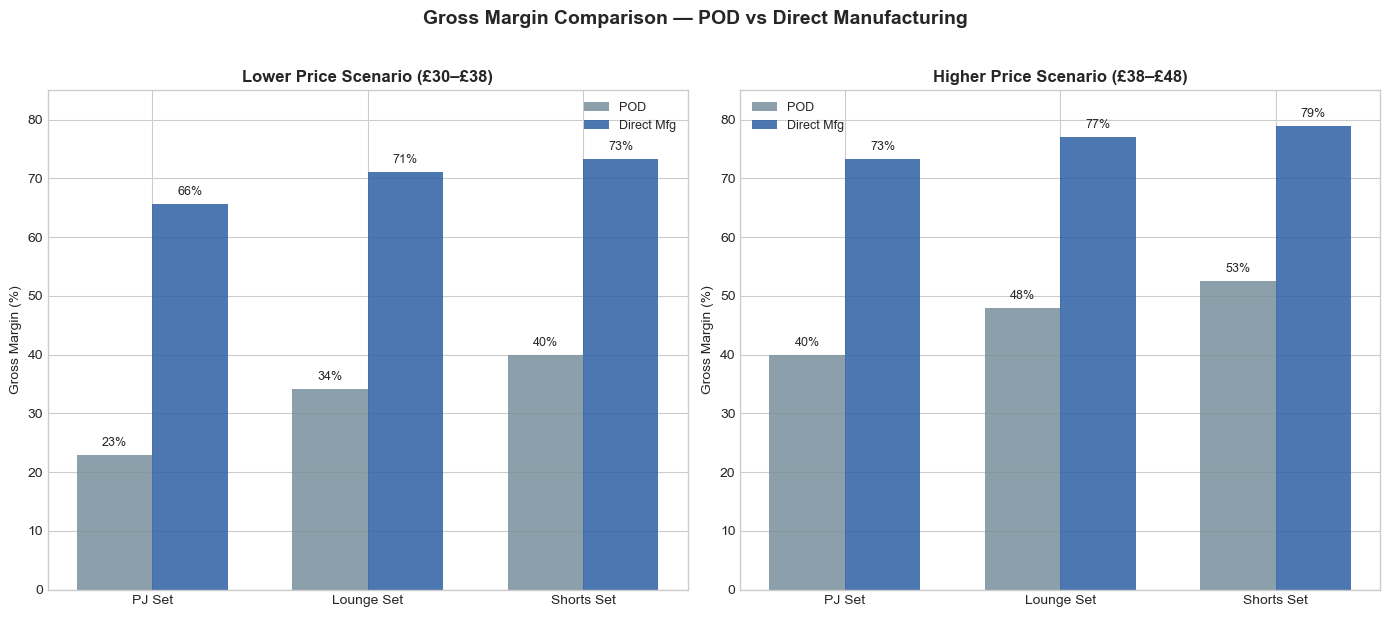

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (price_label, prices) in zip(axes, [('Lower', price_lower), ('Higher', price_higher)]):
    d = df_unit[df_unit['Price Scenario'] == price_label]
    
    x = np.arange(len(products))
    width = 0.35
    
    pod_margins = [d[(d['Product'] == p) & (d['Model'] == 'POD')]['Gross Margin (%)'].values[0] for p in products]
    direct_margins = [d[(d['Product'] == p) & (d['Model'] == 'Direct')]['Gross Margin (%)'].values[0] for p in products]
    
    bars1 = ax.bar(x - width/2, pod_margins, width, label='POD', color='#78909C', alpha=0.85)
    bars2 = ax.bar(x + width/2, direct_margins, width, label='Direct Mfg', color='#2E5FA3', alpha=0.85)
    
    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(x)
    ax.set_xticklabels(products, fontsize=10)
    ax.set_ylabel('Gross Margin (%)', fontsize=10)
    ax.set_ylim(0, 85)
    
    price_range = f'£{min(prices.values())}–£{max(prices.values())}'
    ax.set_title(f'{price_label} Price Scenario ({price_range})',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Gross Margin Comparison — POD vs Direct Manufacturing',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Chart Commentary — Unit Economics

The margin difference between POD and direct manufacturing is stark. At the lower price scenario (£30–38), POD margins are tight — around 22–40% depending on the SKU. PJ sets in particular are squeezed by the high base cost of sublimation printing.

Direct manufacturing roughly doubles the gross margin across all SKUs, bringing PJ sets from ~23% (POD) to ~73% (direct) at the lower price point. This is the fundamental trade-off: POD requires near-zero upfront capital but leaves limited margin for marketing and growth. Direct manufacturing requires inventory investment but provides the margin structure to build a sustainable business.

At the higher price scenario (£38–48), POD becomes viable (~40–58% margins) and direct manufacturing reaches luxury-level margins (~73–83%). The pricing decision directly determines which production model is feasible.

---
## Section 3: 3-Year Revenue Scenarios

In [5]:
def build_pnl(prices, cogs, fixed_costs, volume_scenarios):
    """Build a 3-year P&L for a given production model and price scenario."""
    results = []
    
    for scenario, vols in volume_scenarios.items():
        for year_label, total_orders in vols.items():
            year_num = int(year_label[1])
            
            # Revenue and COGS by product
            revenue = sum(total_orders * product_mix[p] * prices[p] for p in products)
            total_cogs = sum(total_orders * product_mix[p] * cogs[p] for p in products)
            gross_profit = revenue - total_cogs
            
            # Fixed costs (inventory only in Year 1 for direct)
            fixed = sum(v for k, v in fixed_costs.items()
                       if 'inventory' not in k.lower() or year_num == 1)
            
            net_profit = gross_profit - fixed
            
            results.append({
                'Scenario': scenario,
                'Year': year_label,
                'Orders': total_orders,
                'Revenue': round(revenue),
                'COGS': round(total_cogs),
                'Gross Profit': round(gross_profit),
                'Gross Margin %': round(gross_profit / revenue * 100, 1) if revenue > 0 else 0,
                'Fixed Costs': fixed,
                'Net Profit': round(net_profit),
            })
    
    return pd.DataFrame(results)

# Build P&Ls for all combinations
models = {}
for price_label, prices in [('Lower', price_lower), ('Higher', price_higher)]:
    for prod_label, cogs, fixed in [('POD', pod_cogs, fixed_costs_pod),
                                      ('Direct', direct_cogs, fixed_costs_direct)]:
        key = f'{prod_label} — {price_label} Price'
        models[key] = build_pnl(prices, cogs, fixed, volume)

# Display base case for both models at lower price
print('3-YEAR P&L — BASE CASE, LOWER PRICE SCENARIO')
print('=' * 70)
for key in ['POD — Lower Price', 'Direct — Lower Price']:
    print(f'\n{key}:')
    base = models[key][models[key]['Scenario'] == 'Base']
    print(base[['Year', 'Orders', 'Revenue', 'COGS', 'Gross Profit', 'Fixed Costs', 'Net Profit']].to_string(index=False))


3-YEAR P&L — BASE CASE, LOWER PRICE SCENARIO

POD — Lower Price:
Year  Orders  Revenue  COGS  Gross Profit  Fixed Costs  Net Profit
  Y1     250     8662  6038          2625         2942        -317
  Y2     450    15592 10868          4725         2942        1783
  Y3     700    24255 16905          7350         2942        4408

Direct — Lower Price:
Year  Orders  Revenue  COGS  Gross Profit  Fixed Costs  Net Profit
  Y1     250     8662  2675          5988        10742       -4754
  Y2     450    15592  4815         10778         5742        5036
  Y3     700    24255  7490         16765         5742       11023


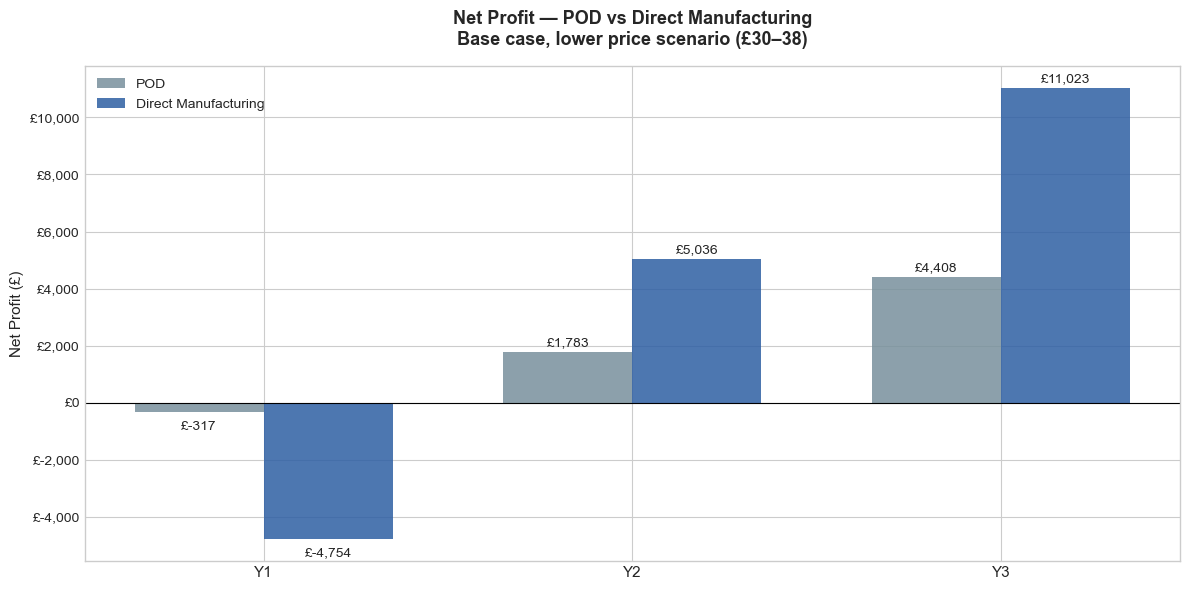

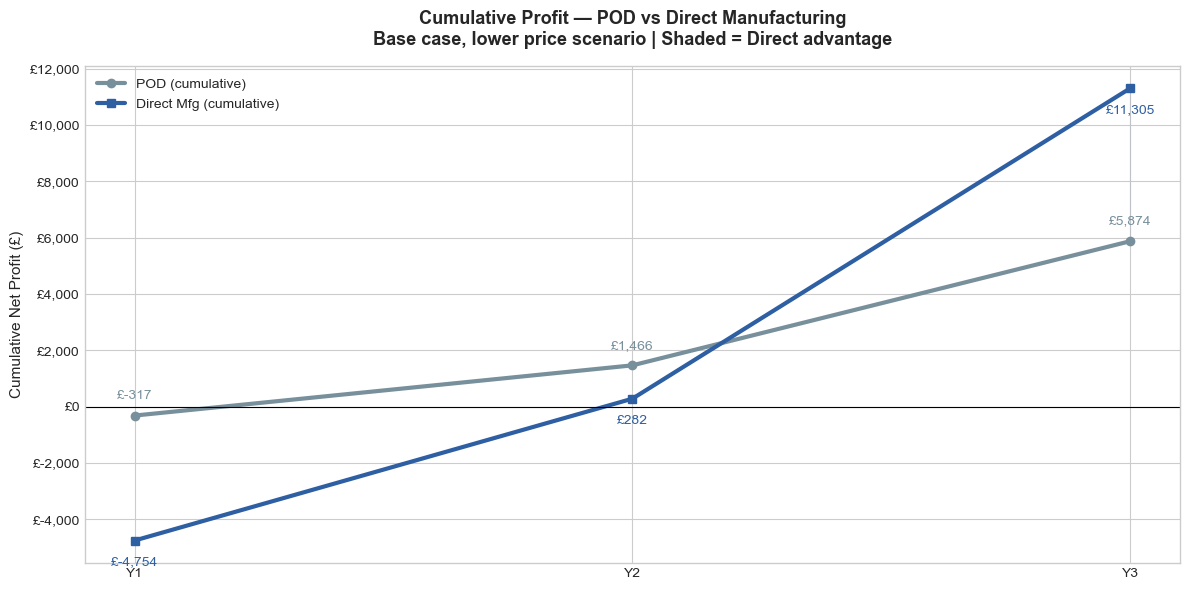

In [6]:
# ── Chart 1: Net Profit — POD vs Direct (Base Case, Lower Price) ─────────
fig, ax = plt.subplots(figsize=(12, 6))

years = ['Y1', 'Y2', 'Y3']
x = np.arange(len(years))
width = 0.35

pod_profit = models['POD — Lower Price'][models['POD — Lower Price']['Scenario'] == 'Base']['Net Profit'].values
direct_profit = models['Direct — Lower Price'][models['Direct — Lower Price']['Scenario'] == 'Base']['Net Profit'].values

bars1 = ax.bar(x - width/2, pod_profit, width, label='POD', color='#78909C', alpha=0.85)
bars2 = ax.bar(x + width/2, direct_profit, width, label='Direct Manufacturing', color='#2E5FA3', alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        y_pos = val + 100 if val >= 0 else val - 300
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'£{val:,.0f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=10)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)
ax.set_ylabel('Net Profit (£)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_title('Net Profit — POD vs Direct Manufacturing\n'
             'Base case, lower price scenario (£30–38)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# ── Chart 2: Cumulative Profit Over 3 Years ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

pod_cum = np.cumsum(pod_profit)
direct_cum = np.cumsum(direct_profit)

ax.plot(years, pod_cum, marker='o', linewidth=3, color='#78909C', label='POD (cumulative)')
ax.plot(years, direct_cum, marker='s', linewidth=3, color='#2E5FA3', label='Direct Mfg (cumulative)')

for yr, pod_v, dir_v in zip(years, pod_cum, direct_cum):
    ax.annotate(f'£{pod_v:,.0f}', xy=(yr, pod_v), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=10, color='#78909C')
    ax.annotate(f'£{dir_v:,.0f}', xy=(yr, dir_v), xytext=(0, -18),
                textcoords='offset points', ha='center', fontsize=10, color='#2E5FA3')

ax.axhline(0, color='black', lw=0.8)
ax.fill_between(years, pod_cum, direct_cum, alpha=0.08, color='#2E5FA3',
                where=[d > p for d, p in zip(direct_cum, pod_cum)])

ax.set_ylabel('Cumulative Net Profit (£)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_title('Cumulative Profit — POD vs Direct Manufacturing\n'
             'Base case, lower price scenario | Shaded = Direct advantage',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Chart Commentary — Profitability Comparison

**Net Profit (Chart 1):** The year-by-year comparison shows the fundamental trade-off. In Year 1, POD may outperform Direct because Direct carries the upfront inventory cost. But as volume grows in Years 2 and 3, Direct's margin advantage compounds — each additional order generates roughly twice the gross profit.

**Cumulative Profit (Chart 2):** This is the chart that answers "which model should I choose?" The crossover point — where Direct's cumulative profit overtakes POD — indicates when the inventory investment pays off. Before that point, POD is the rational choice. After it, Direct is clearly superior.

**The phased strategy emerges from the data:** launch with POD (lower risk, faster to market, profitable at small volume), use early sales to validate demand, then transition to direct manufacturing once volume crosses the threshold where the margin advantage justifies the inventory investment.

---
## Section 4: Break-Even Analysis

In [7]:
# Calculate break-even orders for each model and price scenario
breakeven_rows = []

for price_label, prices in [('Lower', price_lower), ('Higher', price_higher)]:
    for prod_label, cogs, fixed in [('POD', pod_cogs, fixed_costs_pod),
                                      ('Direct', direct_cogs, fixed_costs_direct)]:
        # Blended gross profit per order (weighted by product mix)
        blended_gp = sum(product_mix[p] * (prices[p] - cogs[p]) for p in products)
        
        # Year 1 fixed costs (includes inventory for direct)
        fixed_y1 = sum(fixed.values())
        # Year 2+ fixed costs (excludes one-time inventory)
        fixed_y2 = sum(v for k, v in fixed.items() if 'inventory' not in k.lower())
        
        be_y1 = np.ceil(fixed_y1 / blended_gp) if blended_gp > 0 else float('inf')
        be_y2 = np.ceil(fixed_y2 / blended_gp) if blended_gp > 0 else float('inf')
        
        breakeven_rows.append({
            'Model': prod_label,
            'Price Scenario': price_label,
            'Blended GP/Order (£)': round(blended_gp, 2),
            'Fixed Costs Y1 (£)': fixed_y1,
            'Fixed Costs Y2+ (£)': fixed_y2,
            'Break-Even Orders (Y1)': int(be_y1),
            'Break-Even Orders (Y2+)': int(be_y2),
        })

df_be = pd.DataFrame(breakeven_rows)
print('BREAK-EVEN ANALYSIS')
print('=' * 90)
print(df_be.to_string(index=False))

BREAK-EVEN ANALYSIS
 Model Price Scenario  Blended GP/Order (£)  Fixed Costs Y1 (£)  Fixed Costs Y2+ (£)  Break-Even Orders (Y1)  Break-Even Orders (Y2+)
   POD          Lower                 10.50                2942                 2942                     281                      281
Direct          Lower                 23.95               10742                 5742                     449                      240
   POD         Higher                 20.00                2942                 2942                     148                      148
Direct         Higher                 33.45               10742                 5742                     322                      172


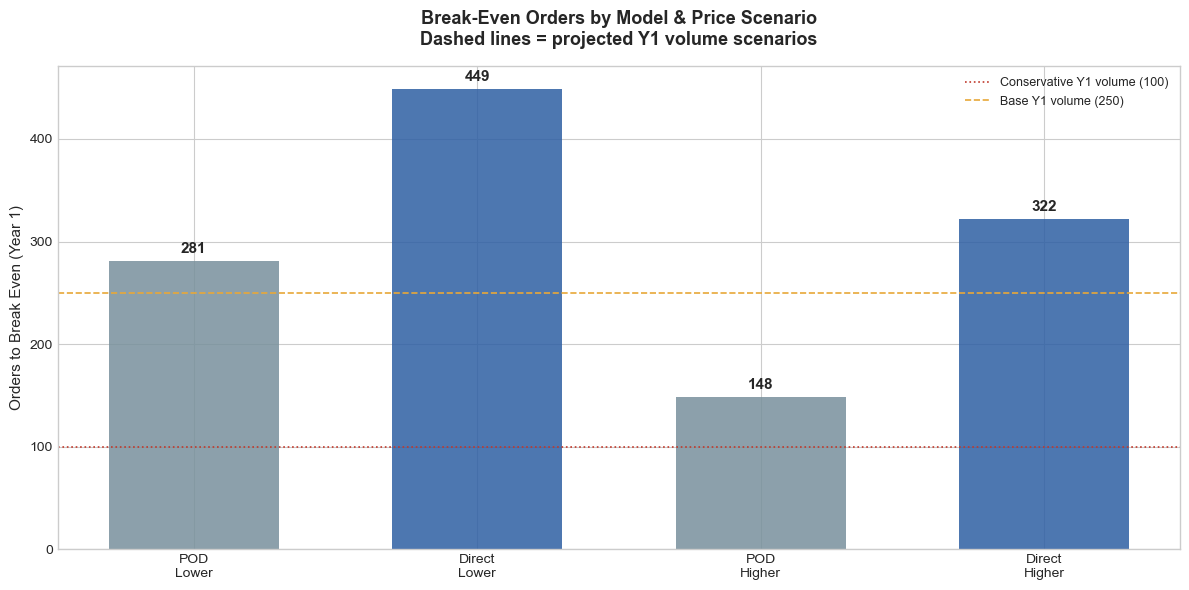

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_be))
labels = [f"{row['Model']}\n{row['Price Scenario']}" for _, row in df_be.iterrows()]
colours_be = ['#78909C' if 'POD' in l else '#2E5FA3' for l in labels]

bars = ax.bar(x, df_be['Break-Even Orders (Y1)'], color=colours_be, alpha=0.85, width=0.6)

for bar, val in zip(bars, df_be['Break-Even Orders (Y1)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Reference lines for volume scenarios
ax.axhline(volume['Conservative']['Y1'], color='#C0392B', ls=':', lw=1.2,
           label=f'Conservative Y1 volume ({volume["Conservative"]["Y1"]})')
ax.axhline(volume['Base']['Y1'], color='#E8A838', ls='--', lw=1.2,
           label=f'Base Y1 volume ({volume["Base"]["Y1"]})')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Orders to Break Even (Year 1)', fontsize=11)
ax.set_title('Break-Even Orders by Model & Price Scenario\n'
             'Dashed lines = projected Y1 volume scenarios',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=9)
ax.set_ylim(0)

plt.tight_layout()
plt.show()

### Chart Commentary — Break-Even

The break-even chart shows how many Year 1 orders are needed to cover fixed costs under each model and price combination.

**POD at higher prices** has the lowest break-even threshold — achievable even under conservative volume assumptions. This is the lowest-risk entry point: minimal capital required, break-even within the first year.

**Direct manufacturing at lower prices** has the highest break-even threshold due to the combination of upfront inventory costs and lower unit revenue. This model only makes sense if volume can reach the base case or above.

**The practical implication:** A bootstrapped launch would likely start with POD to validate demand and build the brand, then transition to direct manufacturing once volume justifies the inventory investment and the higher margins become necessary for scaling marketing spend.

---
## Section 5: Model Comparison Summary

Side-by-side view of all four model/price combinations on key metrics.

In [9]:
# ── Model Comparison Summary ──────────────────────────────────────────────
summary_rows = []

for key, df_pnl in models.items():
    base = df_pnl[df_pnl['Scenario'] == 'Base']
    total_profit = base['Net Profit'].sum()
    y3_margin = base[base['Year'] == 'Y3']['Gross Margin %'].values[0]
    y1_profit = base[base['Year'] == 'Y1']['Net Profit'].values[0]
    y3_revenue = base[base['Year'] == 'Y3']['Revenue'].values[0]
    
    summary_rows.append({
        'Model': key,
        '3-Year Total Profit (£)': total_profit,
        'Y1 Net Profit (£)': y1_profit,
        'Y3 Revenue (£)': y3_revenue,
        'Y3 Gross Margin (%)': y3_margin,
        'Y1 Profitable?': 'Yes' if y1_profit > 0 else 'No',
    })

df_summary = pd.DataFrame(summary_rows)
print('MODEL COMPARISON — BASE CASE')
print('=' * 95)
print(df_summary.to_string(index=False))

MODEL COMPARISON — BASE CASE
                Model  3-Year Total Profit (£)  Y1 Net Profit (£)  Y3 Revenue (£)  Y3 Gross Margin (%) Y1 Profitable?
    POD — Lower Price                     5874               -317           24255                 30.3             No
 Direct — Lower Price                    11305              -4754           24255                 69.1             No
   POD — Higher Price                    19174               2058           30905                 45.3            Yes
Direct — Higher Price                    24603              -2380           30905                 75.8             No


### Commentary — Model Comparison

The comparison table makes the trade-offs explicit across all four combinations:
- **POD + lower price:** lowest risk, lowest return. Suitable for validation.
- **POD + higher price:** viable margins with minimal capital. Best starting point if the brand can command the higher price.
- **Direct + lower price:** only makes sense at scale. The inventory investment is hard to justify at conservative volumes.
- **Direct + higher price:** the strongest long-term model. Best margins, highest 3-year profit, but requires both volume confidence and upfront capital.

The data supports a phased approach: POD at launch (either price point), transitioning to direct manufacturing once demand is validated and volume supports the inventory investment.

---
## Section 6: Key Findings & Limitations

### Summary

1. **POD is the low-risk entry point.** Break-even is achievable at ~100–250 orders depending on pricing. Margins are tight (22–58%) but the model requires near-zero upfront capital and no inventory risk. Suitable for brand validation and early audience building.

2. **Direct manufacturing is the scaling model.** Gross margins of 67–83% provide the headroom needed for paid marketing, influencer partnerships, and brand building. But it requires £5K+ upfront inventory investment and only makes sense above ~300+ annual orders.

3. **Pricing is the critical decision.** The lower price scenario (£30–40) is tight on POD margins but more accessible to the target demographic. The higher scenario (£40–50) makes both models comfortably viable. The right price depends on brand positioning — a question for market testing, not financial modelling.

4. **The phased approach makes sense.** Launch with POD to validate demand and build social presence. Transition to direct manufacturing once monthly order volume justifies inventory investment (likely Year 2 in the base case).

5. **Survival context matters.** Roughly 90% of DTC startups close by their fifth year, with ~30% failing in the first year and ~70% by year three (Source: One Fourth, via inBeat Agency). Most successful clothing startups aim for £1–10M in annual revenue within their first 3–5 years (Source: BusinessDojo). The volume projections in this model are deliberately modest — base case Year 3 revenue of ~£24K is well below these benchmarks, reflecting a bootstrapped niche brand rather than a venture-backed scale play.

### Limitations & Future Enhancements

This model is deliberately simplified. With more time and data, the following would strengthen the analysis:
- **Customer acquisition cost (CAC) modelling** — paid social, influencer gifting ROI, organic conversion rates
- **Cohort-based LTV analysis** — repeat purchase rates, average order frequency, retention curves
- **Sensitivity analysis** — systematic testing of how changes in price, COGS, volume, and CAC affect profitability
- **Seasonality adjustment** — the 5x November uplift (from notebook 02) means revenue is heavily concentrated in Q4; a monthly model would capture this
- **Cash flow modelling** — particularly important for the direct manufacturing model where inventory is purchased months before revenue is received
- **US expansion scenario** — separate model with US-specific pricing, shipping, and marketing assumptions

---

*This is an illustrative financial model for analytical purposes. All assumptions are documented and adjustable. It is not a forecast or investment recommendation.*